# Práctica semanal

En esta práctica, trabajaremos dos proyectos distintos, uno de clasificación binaria y otro de clasificación multiclase. 

## Clasificación binaria

Nuestro dataset se encuentra en el archivo ``data/transfusion.csv``. Cada línea contiene información de donantes de sangre y tiene las siguientes columnas:

- ``meses_ultima``: número de meses desde la última donación de sangre
- ``frecuencia``: número de veces que la persona ha donado sangre
- ``volumen``: cantidad total de sangre (en ml) donada por la persona
- ``meses_primera``: número de meses desde la primera donación de sangre
- ``donante``: si la persona ha donado sangre durante el último mes

Nuestro propósito es construir la función ``es_donante(meses_ultima, frecuencia, volumen, meses_primera)`` la cual devuelve ``True`` si se predice que la persona donaría sangre el próximo mes, ``False`` si no.

In [1]:
 # Cargamos bibliotecas importantes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

# Cargamos el dataset de transfusion
transfusion_data = pd.read_csv('data/transfusion.csv')

In [2]:
# EJERCICIO (1pt): Colocar los datos en formato numpy

transfusion_x = transfusion_data.loc[:, ['meses_ultima', 'frecuencia', 'volumen', 'meses_primera']] # Independientes: contiene las columnas meses_ultima, frecuencia, volumen y meses_primera
transfusion_y =  transfusion_data.loc[:, 'donante'] # Dependiente: contiene la columna donante
transfusion_y_n = transfusion_y.to_numpy()
transfusion_x_n = transfusion_x.to_numpy()
print(transfusion_x_n)

[[    2    50 12500    98]
 [    0    13  3250    28]
 [    1    16  4000    35]
 ...
 [   23     3   750    62]
 [   39     1   250    39]
 [   72     1   250    72]]


In [3]:
# EJERCICIO (2pt): Entrenar un modelo de regresión logística con scikit-learn
X_train, X_test, y_train, y_test = train_test_split(transfusion_x_n, transfusion_y_n, test_size=0.2, random_state=42)
transfusion_modelo = LogisticRegression()
transfusion_modelo.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [4]:
# EJERCICIO (2pt): Crear una función de predicción
def es_donante(meses_ultima, frecuencia, volumen, meses_primera):
    pred = transfusion_modelo.predict([[meses_ultima, frecuencia, volumen, meses_primera]])
    return bool(pred[0])

In [5]:
# --- CELDA PARA PROBAR SU MODELO UNA VEZ ESTÉ ENTRENADO --- #

## Precisión del modelo debe ser aproximadamente 0.77
print('Precisión: ', (transfusion_modelo.predict(transfusion_x) == transfusion_y).mean())

# Debe dar False
print('es_donante(3, 20, 1000, 8): ', es_donante(3, 20, 1000, 8))

# Debe dar True
print('es_donante(6, 12, 5000, 20): ', es_donante(6, 12, 5000, 20))

Precisión:  0.7713903743315508
es_donante(3, 20, 1000, 8):  False
es_donante(6, 12, 5000, 20):  True


c:\Python\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## Clasificación multiclase

Nuestro dataset se encuentra en el archivo ``data/provincias.csv``, el cual contiene 484 observaciones de puntos de latitud (columna ``lat``) y longitud (columna ``long``) en el territorio nacional, con una variable ``provincia`` que indica en qué provincia se ubica cada punto. 

Nuestro propósito es construir una función ``cual_provincia(latitud, longitud)`` la cual devuelve el nombre de la provincia y su probabilidad correspondiente. 

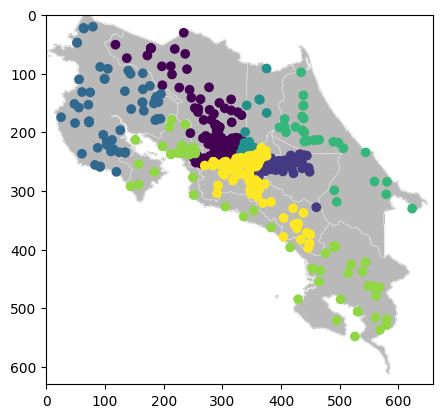

In [6]:
# Cargamos el dataset de provincias
provincias_data = pd.read_csv('data/provincias_scaled.csv')

# Y mostramos los puntos en el mapa
# Primero, codifiquemos las provincias en 0-6
le = preprocessing.LabelEncoder()
le.fit(provincias_data['provincia'])
c = le.transform(provincias_data['provincia'])

# Leemos el archivo
im = plt.imread('data/mapaCR.png')
implot = plt.imshow(im)

# Escalamos los arrays en 0-1
p_long = provincias_data['long']
p_lat = provincias_data['lat']

# Dibujamos (con un pequeño offset empírico para que caiga en la imágen)
plt.scatter((im.shape[0]*p_long)*0.95 + 25, (im.shape[1]*(1-p_lat))*0.8 + 20, c=c)

In [7]:
# EJERCICIO (2pt): Entrenar un modelo de regresión softmax para distinguir la probabilidad de que un punto 
# esté en cada provincia
# *** NOTA IMPORTANTE: para los datos de entrenamiento, vamos a utilizar los arrays escalados "p_long" y "p_lat"

provincias_model = LogisticRegression().fit(np.array([p_long, p_lat]).T, provincias_data['provincia'])


In [8]:
# EJERCICIO (2pt): Función que devuelve un diccionario con la probabilidad de que un punto (longitud, latitud) 
# se encuentre en una provincia dada, 
# p.ej. {'ALAJUELA': 0.3, 'CARTAGO': 0.1, 'PUNTARENAS': 0.1, 
#        'LIMON': 0.1 'GUANACASTE': 0.1, 'HEREDIA': 0.2, 'SAN JOSE': 0.1}
p_long_n = p_long.to_numpy()
p_lat_n = p_lat.to_numpy()
def prob_provincias(long, lat):
    input = [p_long_n, p_lat_n]
    output= provincias_model.predict_proba(input)
    le_output = dict(zip(provincias_model.classes_, output))
    return le_output

In [9]:
# EJERCICIO (1pt): Función que devuelve la provincia de mayor probabilidad a la que un punto (longitud, latitud)
# pertenece.

def cual_provincia(long, lat):
    
    output = provincias_model.predict([p_long_n, p_lat_n])
    return output

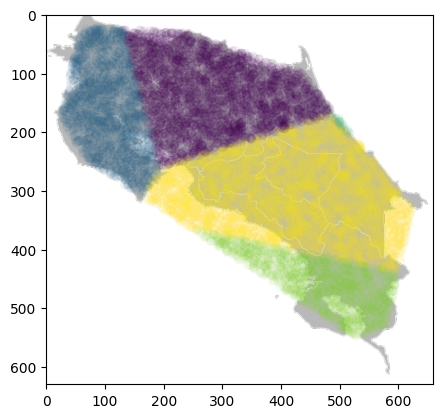

In [10]:
# --- CELDA PARA PROBAR SU MODELO UNA VEZ ESTÉ ENTRENADO --- #

from scipy.spatial import Delaunay
points = np.array((p_long_n, p_lat_n)).T
hull = Delaunay(points)

samples = np.random.rand(20000,2)
samples = np.array([x for x in samples if hull.find_simplex(x) >= 0]).T

im = plt.imread('data/mapaCR.png')
implot = plt.imshow(im)

plt.scatter((samples[0]*im.shape[0])*0.95 + 25, ((1.0-samples[1])*im.shape[1])*0.8 + 20, c=le.transform(provincias_model.predict(samples.T)), alpha=0.05)